In [20]:
import pandas as pd
from exercises import EXERCISE_NAMES

In [21]:
data=pd.read_csv('workouts.csv')

In [22]:

data['volume']=data['weight']*data['reps']

In [30]:
data["weight_kg"] = data.apply(
    lambda row: row["weight"] * 0.453592 if row["unit"] == "lbs" else row["weight"],
    axis=1
)

data["weight_lbs"] = data.apply(
    lambda row: round(row["weight"] / 0.453592) if row["unit"] == "kg" else row["weight"],
    axis=1
)

In [31]:
data

,date,exercise,set_number,weight,reps,unit,volume,weight_kg,weight_lbs
0,2025-01-21,Over Hand Row,1,23.0,10,kg,230.0,23.0,51.0
1,2025-01-21,Over Hand Row,2,32.0,10,kg,320.0,32.0,71.0
2,2025-01-21,Over Hand Row,3,36.0,10,kg,360.0,36.0,79.0
3,2025-01-21,Shoulder Press,1,25.0,10,kg,250.0,25.0,55.0
4,2025-01-21,Shoulder Press,2,30.0,10,kg,300.0,30.0,66.0
...,...,...,...,...,...,...,...,...,...
387,2025-04-15,Straight Bar Lat Prayer,2,19.3,10,kg,193.0,19.3,43.0
388,2025-04-15,Straight Bar Lat Prayer,3,22.7,10,kg,227.0,22.7,50.0
389,2025-04-15,Cable Fly,1,13.6,10,kg,136.0,13.6,30.0
390,2025-04-15,Cable Fly,2,15.9,10,kg,159.0,15.9,35.0


In [32]:
data.to_csv('workouts_processed.csv', index=None)

In [33]:
data.head()

,date,exercise,set_number,weight,reps,unit,volume,weight_kg,weight_lbs
0,2025-01-21,Over Hand Row,1,23.0,10,kg,230.0,23.0,51.0
1,2025-01-21,Over Hand Row,2,32.0,10,kg,320.0,32.0,71.0
2,2025-01-21,Over Hand Row,3,36.0,10,kg,360.0,36.0,79.0
3,2025-01-21,Shoulder Press,1,25.0,10,kg,250.0,25.0,55.0
4,2025-01-21,Shoulder Press,2,30.0,10,kg,300.0,30.0,66.0


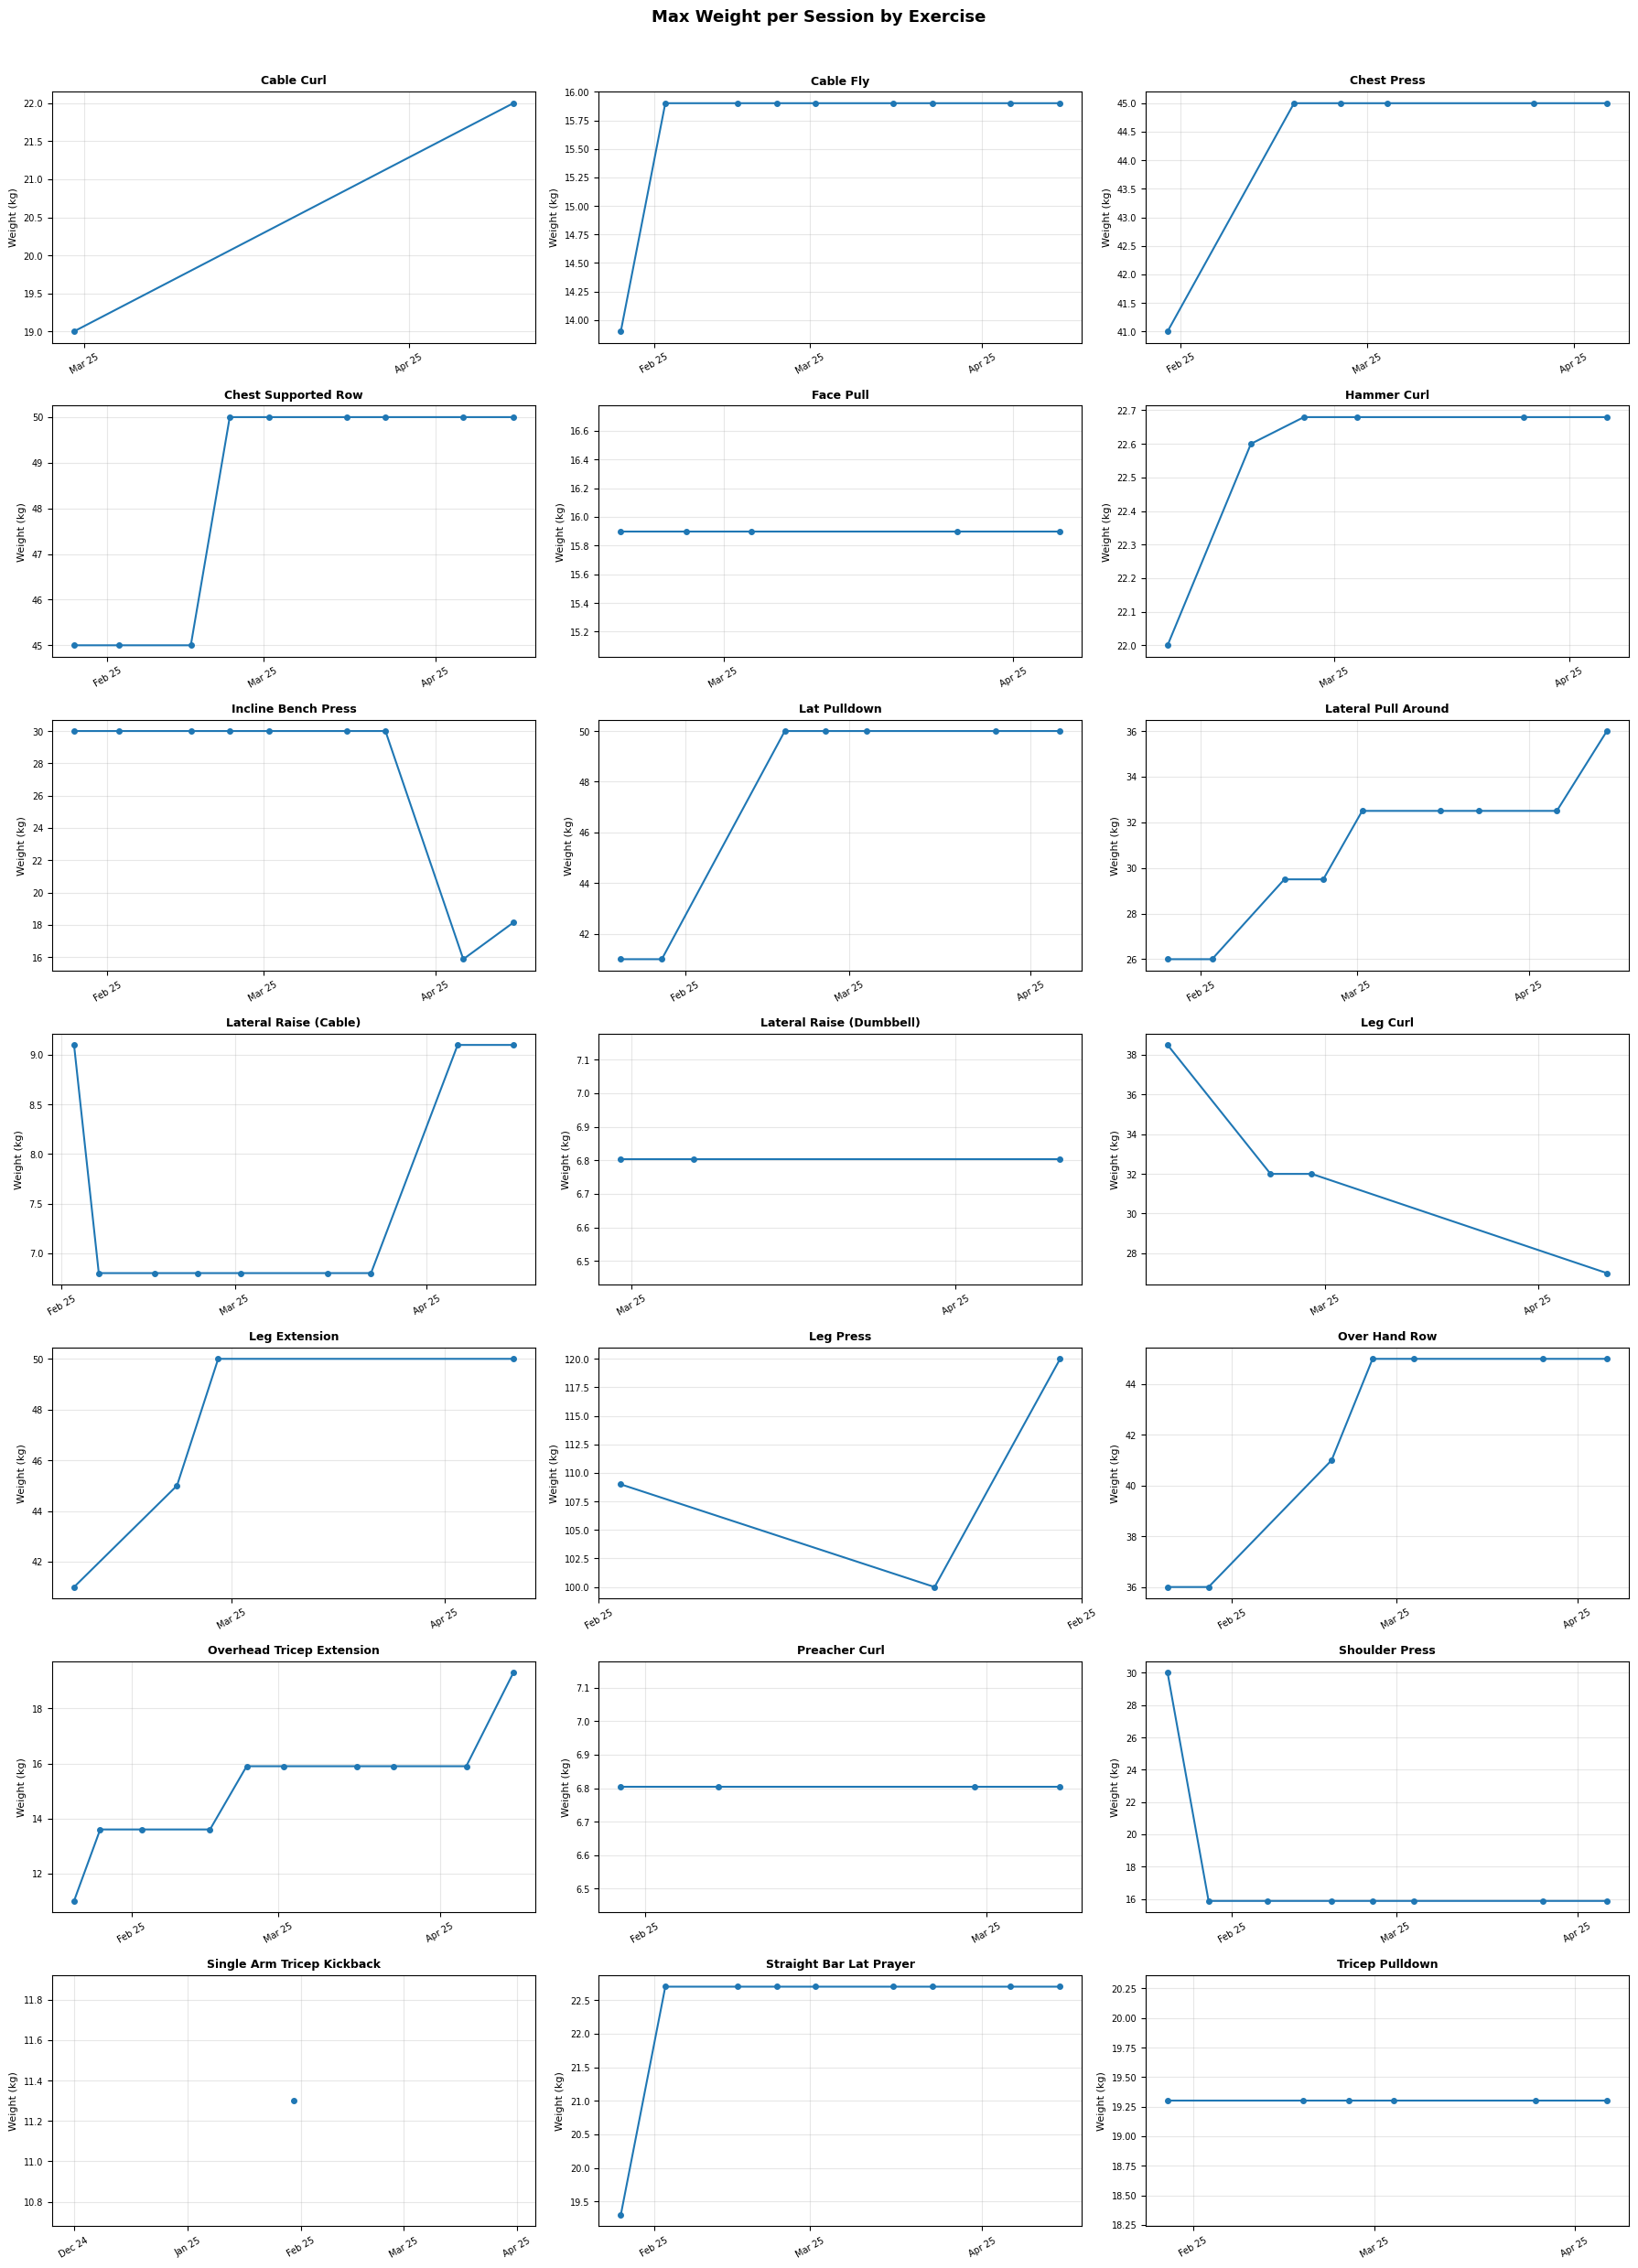

In [34]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Use max weight per exercise per date (best set each day)
daily_max = data.groupby(['date', 'exercise'])['weight_kg'].max().reset_index()
daily_max['date'] = pd.to_datetime(daily_max['date'])

exercises = daily_max['exercise'].unique()
n_cols = 3
n_rows = -(-len(exercises) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
axes = axes.flatten()

for i, exercise in enumerate(sorted(exercises)):
    ax = axes[i]
    ex_data = daily_max[daily_max['exercise'] == exercise].sort_values('date')
    ax.plot(ex_data['date'], ex_data['weight_kg'], marker='o', linewidth=1.5, markersize=4)
    ax.set_title(exercise, fontsize=9, fontweight='bold')
    ax.set_ylabel('Weight (kg)', fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.tick_params(axis='x', labelsize=7, rotation=30)
    ax.tick_params(axis='y', labelsize=7)
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Max Weight per Session by Exercise', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [ ]:
# Total volume per exercise per date (sum across all sets)
daily_vol = data.groupby(['date', 'exercise'])['volume'].sum().reset_index()
daily_vol['date'] = pd.to_datetime(daily_vol['date'])

exercises = daily_vol['exercise'].unique()
n_cols = 3
n_rows = -(-len(exercises) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
axes = axes.flatten()

for i, exercise in enumerate(sorted(exercises)):
    ax = axes[i]
    ex_data = daily_vol[daily_vol['exercise'] == exercise].sort_values('date')
    ax.bar(ex_data['date'], ex_data['volume'], width=3, color='steelblue', alpha=0.8)
    ax.set_title(exercise, fontsize=9, fontweight='bold')
    ax.set_ylabel('Volume (kg)', fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.tick_params(axis='x', labelsize=7, rotation=30)
    ax.tick_params(axis='y', labelsize=7)
    ax.grid(True, alpha=0.3, axis='y')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Total Volume per Session by Exercise (weight × reps)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
